Please visit the link for all files assosiated!

https://github.com/elliotthull/Math104C-Advanced-Numerical-Analysis-Final-Project-I

Introduction:

Ordinary Differential Equations (ODEs) arise naturally across science and engineering — from population dynamics and chemical reactions to electrical circuits and astrophysics. While many ODEs lack closed-form solutions, numerical methods allow us to approximate them to high accuracy. In this project, we investigate eight numerical solvers and analyze their behavior across several key problem settings.

Numerical Methods:

We will examine methods spanning three levels of complexity. The Euler and Taylor 2nd-order methods are simple single-step schemes, with Taylor gaining accuracy as it uses derivative information to shrink that error. The Midpoint, Heun's, and RK4 methods are Runge-Kutta-type solvers that evaluate the right-hand side at intermediate points, with RK4 serving as the gold standard for single-step integration. Finally, Adams-Bashforth, Adams-Moulton, and the Predictor-Corrector are multi-step methods that achieve high accuracy with fewer function evaluations per step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Euler method
def euler(f, a, b, N, alpha):
    #create grid and time vector
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)

    w = np.zeros(N + 1)
    w[0] = alpha
    #loop for euler method
    for i in range(N):
        w[i + 1] = w[i] + h * f(t[i], w[i])
    return t, w


In [3]:
# Taylor 2nd-order method
def taylor2(f, f_prime, a, b, N, alpha):
    #create grid and time vector
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha
    #loop
    for i in range(N):
        #T_2 truncation error
        T_2 = f(t[i], w[i]) + (h / 2) * f_prime(t[i], w[i])
        
        w[i + 1] = w[i] + h * T_2
    return t, w


In [4]:
# Midpoint method
def midpoint(f, a, b, N, alpha):
    #create grid and time vector
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha
    #loops for midpoint
    for i in range(N):
        w[i + 1] = w[i] + h * f(t[i] + h / 2, w[i] + (h / 2) * f(t[i], w[i]))
    return t, w


In [5]:
# Heun's 3rd-order method
def heuns(f, a, b, N, alpha):
    #create grid
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha
    for i in range(N):
        w[i + 1] = w[i] + (h / 4) * (
            f(t[i], w[i])
            + 3 * f(
                t[i] + (2 * h) / 3,
                w[i] + (2 * h / 3) * f(t[i] + h / 3, w[i] + (h / 3) * f(t[i], w[i]))
            )
        )
    return t, w


In [6]:
# Runge-Kutta 4th-order (RK4)
def RK4(f, a, b, N, alpha):
    #create grid
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha
    for i in range(N):
        #calculate 4 functions for next iteration update
        k1 = h * f(t[i], w[i])
        k2 = h * f(t[i] + h / 2, w[i] + k1 / 2)
        k3 = h * f(t[i] + h / 2, w[i] + k2 / 2)
        k4 = h * f(t[i + 1], w[i] + k3)
        w[i + 1] = w[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t, w


In [7]:
# Adams-Bashforth 4-step explicit method
def adams_bashforth(f, a, b, N, alpha):
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha
    # Bootstrap first 3 steps with RK4
    for i in range(3):
        k1 = h * f(t[i], w[i])
        k2 = h * f(t[i] + h / 2, w[i] + k1 / 2)
        k3 = h * f(t[i] + h / 2, w[i] + k2 / 2)
        k4 = h * f(t[i] + h, w[i] + k3)
        w[i + 1] = w[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    # Adams-Bashforth 4-step formula
    for i in range(3, N):
        w[i + 1] = w[i] + (h / 24) * (
            55 * f(t[i],     w[i])
          - 59 * f(t[i - 1], w[i - 1])
          + 37 * f(t[i - 2], w[i - 2])
          -  9 * f(t[i - 3], w[i - 3])
        )
    return t, w


In [8]:
# Adams-Moulton 3-step implicit method
def adams_moulten(f, a, b, N, alpha):
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w = np.zeros(N + 1)
    w[0] = alpha

    # 2 steps with RK4
    for i in range(2):
        k1 = h * f(t[i], w[i])
        k2 = h * f(t[i] + h / 2, w[i] + k1 / 2)
        k3 = h * f(t[i] + h / 2, w[i] + k2 / 2)
        k4 = h * f(t[i] + h, w[i] + k3)
        w[i + 1] = w[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    for i in range(2, N):
        # Predictor (Adams-Bashforth 3-step)
        w_pred = w[i] + (h / 12) * (
            23 * f(t[i],     w[i])
          - 16 * f(t[i - 1], w[i - 1])
          +  5 * f(t[i - 2], w[i - 2])
        )
        # Corrector (Adams-Moulton 3-step)
        w[i + 1] = w[i] + (h / 24) * (
             9 * f(t[i + 1], w_pred)
          + 19 * f(t[i],     w[i])
          -  5 * f(t[i - 1], w[i - 1])
          +      f(t[i - 2], w[i - 2])
        )
    return t, w


In [9]:
def predictor_corrector(f, a, b, N, alpha):
    h = (b - a) / N
    t = np.linspace(a, b, N + 1)
    w   = np.zeros(N + 1)
    w_p = np.zeros(N + 1)
    w[0] = w_p[0] = alpha

    # First 3 steps with RK4
    for i in range(3):
        k1 = h * f(t[i], w[i])
        k2 = h * f(t[i] + h / 2, w[i] + k1 / 2)
        k3 = h * f(t[i] + h / 2, w[i] + k2 / 2)
        k4 = h * f(t[i] + h, w[i] + k3)
        w[i + 1] = w_p[i + 1] = w[i] + (k1 + 2*k2 + 2*k3 + k4) / 6

    # Adams-Bashforth 4-step predictor + Adams-Moulton 4-step corrector
    for i in range(3, N):
        # Predictor
        w_p[i + 1] = w[i] + (h / 24) * (
              55 * f(t[i],     w[i])
            - 59 * f(t[i - 1], w[i - 1])
            + 37 * f(t[i - 2], w[i - 2])
            -  9 * f(t[i - 3], w[i - 3])
        )
        # Corrector
        w[i + 1] = w[i] + (h / 24) * (
              9 * f(t[i + 1], w_p[i + 1])
            + 19 * f(t[i],     w[i])
            -  5 * f(t[i - 1], w[i - 1])
            +      f(t[i - 2], w[i - 2])
        )

    return t, w

## Problem A)


In [10]:
# ODE: y' = y - t^2 + 1,  y(0) = 1
# Exact solution: y(t) = (t+1)^2 - 0.5 * exp(t)

def f_1(t, y):
    return y - t**2 + 1

def f_1_p(t, y):  
    return y - t**2 - 2*t + 1


def y_exact(t):
    return (t + 1)**2 - 0.5 * np.exp(t)


N_s = [10, 20, 40]

results = {}
for N in N_s:
    results[N] = {
        'euler':     euler(f_1, 0, 2, N, alpha=0.5),
        'taylor':    taylor2(f_1, f_1_p, 0, 2, N, alpha=0.5),
        'midpoint':  midpoint(f_1, 0, 2, N, alpha=0.5),
        'heuns':     heuns(f_1, 0, 2, N, alpha=0.5),
        'RK4':       RK4(f_1, 0, 2, N, alpha=0.5),
        'adams_b':   adams_bashforth(f_1, 0, 2, N, alpha=0.5),
        'adams_m':   adams_moulten(f_1, 0, 2, N, alpha=0.5),
        'pred_cor':  predictor_corrector(f_1, 0, 2, N, alpha=0.5),
    }



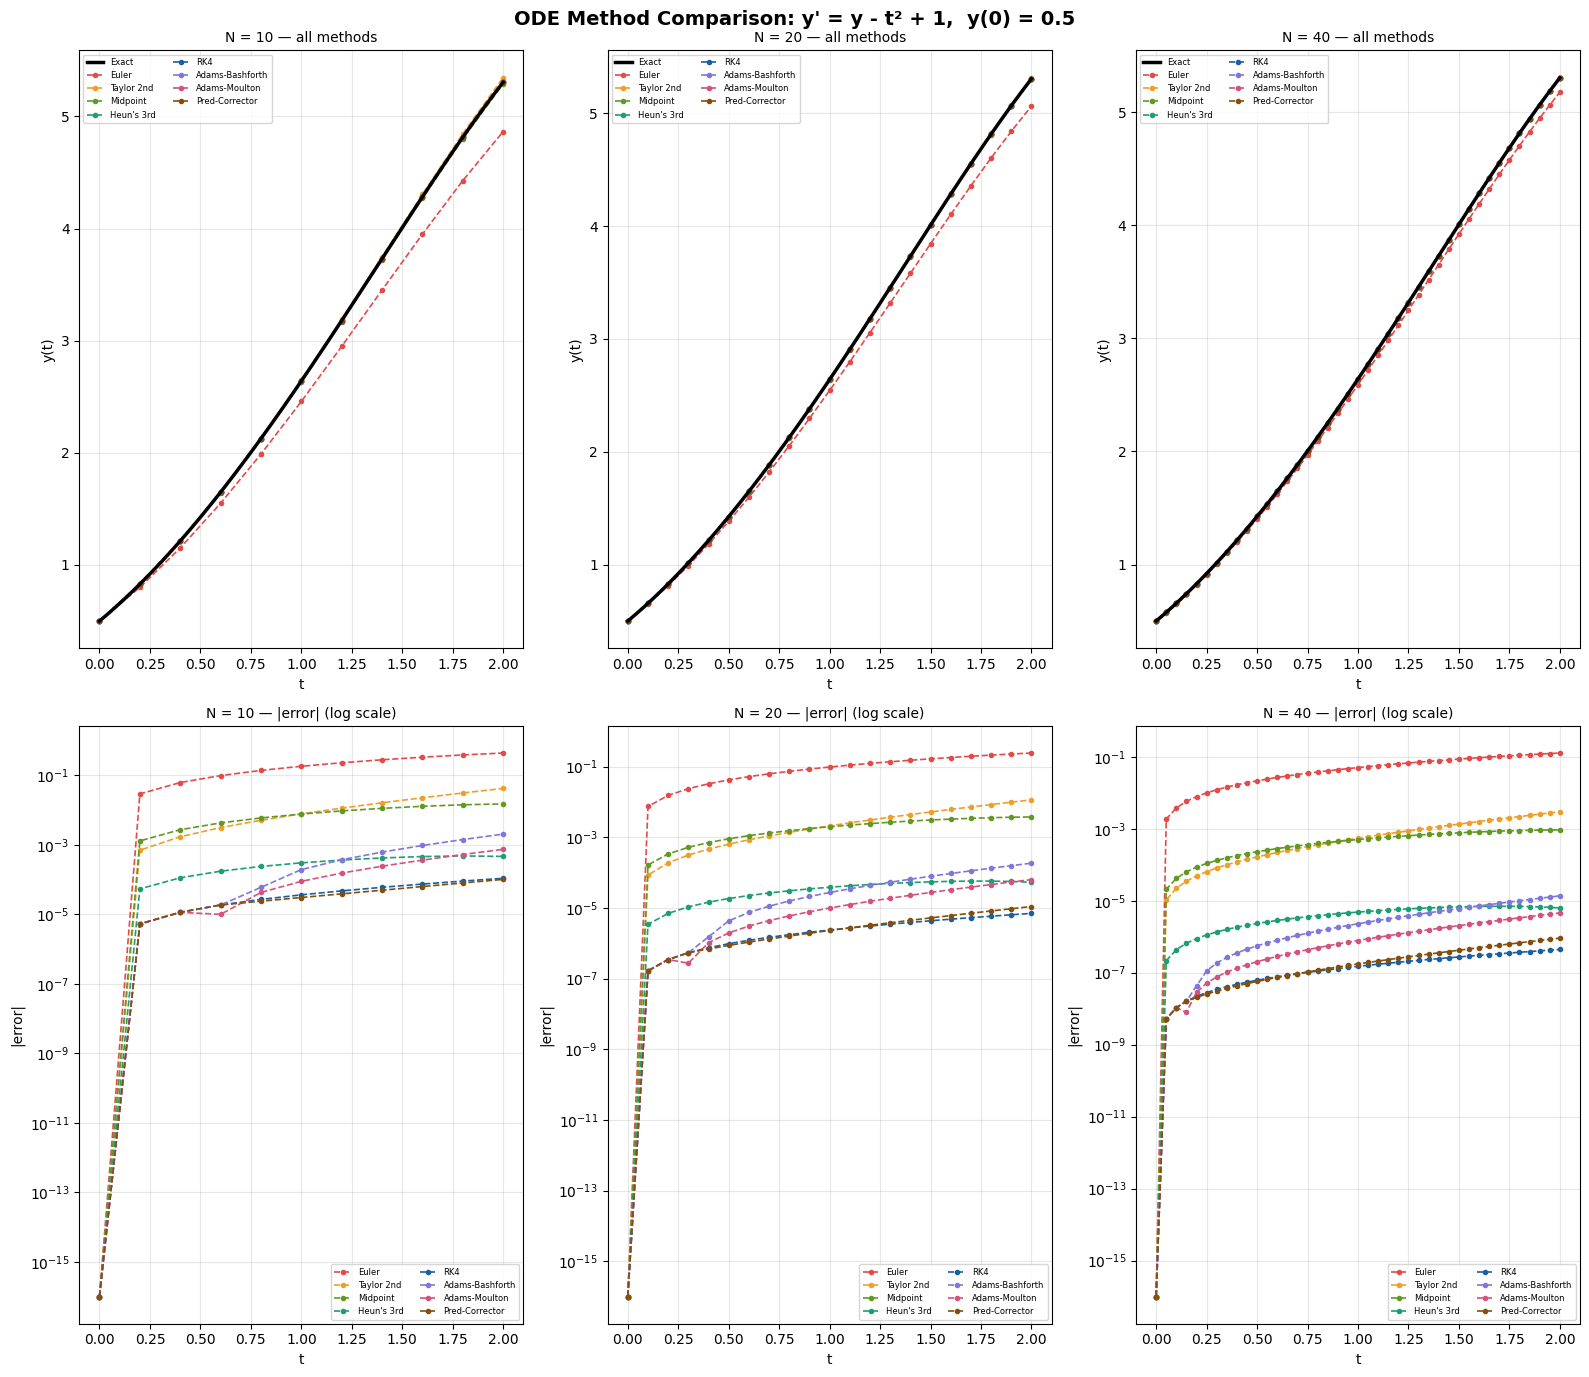

In [11]:
#graphing and numerical results
method_keys   = ['euler', 'taylor', 'midpoint', 'heuns', 'RK4', 'adams_b', 'adams_m', 'pred_cor']
method_labels = ['Euler', 'Taylor 2nd', 'Midpoint', "Heun's 3rd", 'RK4',
                 'Adams-Bashforth', 'Adams-Moulton', 'Pred-Corrector']

fig, axes = plt.subplots(2, 3, figsize=(16, 14))
fig.suptitle("ODE Method Comparison: y' = y - t² + 1,  y(0) = 0.5", fontsize=14, fontweight='bold')

colors = ['#E24B4A', '#EF9F27', '#639922', '#1D9E75', '#185FA5', '#7F77DD', '#D4537E', '#854F0B']

for col, N in enumerate(N_s):
    t_fine = np.linspace(0, 2, 300)

    ax_top = axes[0][col]
    ax_top.plot(t_fine, y_exact(t_fine), 'k-', linewidth=2.5, label='Exact', zorder=10)
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results[N][key]
        ax_top.plot(t_m, w_m, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_top.set_title(f'N = {N} — all methods', fontsize=10)
    ax_top.set_xlabel('t')
    ax_top.set_ylabel('y(t)')
    ax_top.legend(fontsize=6, ncol=2)
    ax_top.grid(True, alpha=0.3)


    ax_mid = axes[1][col]
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results[N][key]
        err = np.abs(w_m - y_exact(t_m))
        ax_mid.semilogy(t_m, err + 1e-16, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_mid.set_title(f'N = {N} — |error| (log scale)', fontsize=10)
    ax_mid.set_xlabel('t')
    ax_mid.set_ylabel('|error|')
    ax_mid.legend(fontsize=6, ncol=2)
    ax_mid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
#create numerical tables for comparison
for N in N_s:
    t_vals = results[N]['euler'][0]   # all methods share the same t 
    exact_vals = y_exact(t_vals)

    data = {'t': t_vals, 'Exact': exact_vals}
    for key, label in zip(method_keys, method_labels):
        _, w = results[N][key]
        data[label] = w

    df = pd.DataFrame(data)

    max_row = {'t': 'max |error|', 'Exact': ''}
    for key, label in zip(method_keys, method_labels):
        _, w = results[N][key]
        max_row[label] = np.max(np.abs(w - y_exact(t_vals)))
    df = pd.concat([df, pd.DataFrame([max_row])], ignore_index=True)

    print(f'\n{"="*60}')
    print(f'  N = {N}  (h = {2/N:.4f})')
    print(f'{"="*60}')


    float_cols = [c for c in df.columns if c != 't']
    pd.set_option('display.float_format', '{:.8f}'.format)
    pd.set_option('display.max_columns', 20)
    pd.set_option('display.width', 220)
    print(df.to_string(index=False))



  N = 10  (h = 0.2000)
          t      Exact      Euler  Taylor 2nd   Midpoint  Heun's 3rd        RK4  Adams-Bashforth  Adams-Moulton  Pred-Corrector
 0.00000000 0.50000000 0.50000000  0.50000000 0.50000000  0.50000000 0.50000000       0.50000000     0.50000000      0.50000000
 0.20000000 0.82929862 0.80000000  0.83000000 0.82800000  0.82924444 0.82929333       0.82929333     0.82929333      0.82929333
 0.40000000 1.21408765 1.15200000  1.21580000 1.21136000  1.21397499 1.21407621       1.21407621     1.21407621      1.21407621
 0.60000000 1.64894060 1.55040000  1.65207600 1.64465920  1.64876590 1.64892202       1.64892202     1.64895060      1.64892202
 0.80000000 2.12722954 1.98848000  2.13233272 2.12128422  2.12699053 2.12720268       2.12728925     2.12727223      2.12720563
 1.00000000 2.64085909 2.45817600  2.64864592 2.63316675  2.64055555 2.64082269       2.64105333     2.64094815      2.64082860
 1.20000000 3.17994154 2.94981120  3.19134802 3.17046344  3.17957629 3.17989417 

In [13]:
#error tables for comparison
import pandas as pd

method_keys   = ['euler', 'taylor', 'midpoint', 'heuns', 'RK4', 'adams_b', 'adams_m', 'pred_cor']
method_labels = ['Euler', 'Taylor 2nd', 'Midpoint', "Heun's 3rd", 'RK4',
                 'Adams-Bashforth', 'Adams-Moulton', 'Pred-Corrector']

for N in N_s:
    h = 2 / N
    t_vals     = results[N]['euler'][0]
    exact_vals = y_exact(t_vals)

    data = {'t': np.round(t_vals, 4), 'Exact': exact_vals}
    for key, label in zip(method_keys, method_labels):
        _, w = results[N][key]
        data[label] = np.abs(w - exact_vals)

    df = pd.DataFrame(data)

    # format: exact in regular float, errors in scientific notation
    fmt = {'Exact': '{:.6f}'.format}
    for label in method_labels:
        fmt[label] = '{:.2e}'.format

    print(f'\nError table  |  h = {h}  (N = {N})\n')
    print(df.to_string(index=False, formatters=fmt))
    print()


Error table  |  h = 0.2  (N = 10)

         t    Exact    Euler Taylor 2nd Midpoint Heun's 3rd      RK4 Adams-Bashforth Adams-Moulton Pred-Corrector
0.00000000 0.500000 0.00e+00   0.00e+00 0.00e+00   0.00e+00 0.00e+00        0.00e+00      0.00e+00       0.00e+00
0.20000000 0.829299 2.93e-02   7.01e-04 1.30e-03   5.42e-05 5.29e-06        5.29e-06      5.29e-06       5.29e-06
0.40000000 1.214088 6.21e-02   1.71e-03 2.73e-03   1.13e-04 1.14e-05        1.14e-05      1.14e-05       1.14e-05
0.60000000 1.648941 9.85e-02   3.14e-03 4.28e-03   1.75e-04 1.86e-05        1.86e-05      1.00e-05       1.86e-05
0.80000000 2.127230 1.39e-01   5.10e-03 5.95e-03   2.39e-04 2.69e-05        5.97e-05      4.27e-05       2.39e-05
1.00000000 2.640859 1.83e-01   7.79e-03 7.69e-03   3.04e-04 3.64e-05        1.94e-04      8.91e-05       3.05e-05
1.20000000 3.179942 2.30e-01   1.14e-02 9.48e-03   3.65e-04 4.74e-05        3.73e-04      1.54e-04       3.89e-05
1.40000000 3.732400 2.81e-01   1.62e-02 1.12e-02   4

Problem A uses the ODE $y^{'} = y - t^2 + 1$ with exact solution $y(t) = (t+1)^2 - \frac{1}{2} e^t$. Because the solution is smooth and non-stiff, it provides an excellent test of convergence behavior. The numerical results clearly reflect the theoretical orders of the methods. At t=2, Euler's error decreases from approximately $4.40 * e^{-1}$
for N=10 to $2.42 * e^{-1}$ for N=20, and then to roughly $1.27 * e^{-1}$ for N=40, demonstrating first-order convergence. The second-order methods (Taylor and Midpoint) show much faster improvement. Taylor's error falls from approximately $4.22 * e^{-02}$ to $2.96 * e^{-03}$, while the Midpoint method decreases from $1.51 * e^{-02}$ to roughly $9.28 * e^{-04}$ .Higher-order methods perform dramatically better as expected. Heun's method, RK4, Adams-Moulton, and the Predictor-Corrector method all produce errors several orders of magnitude smaller than Euler's method. In the plots, the RK4 and multistep solutions are nearly indistinguishable from the exact solution, even with relatively large step sizes. As the step size decreases, the errors consistently decrease at rates predicted by the theoretical convergence orders, confirming the expected relationship between local truncation error and global error.

Problem B)

In [14]:
def f_2(t, y):
    #problem 
    return 2*y

def y_exact_2(t):
    #exact solutio 
    return np.exp(2*t)

def f_2_p(t,y):
    #derivative
    return 2 * np.exp(2*t)

#step sizes
N_s = [10, 20, 40]

results_2 = {}
for N in N_s:
    results_2[N] = {
        'euler':     euler(f_2, 0, 2, N, alpha=1),
        'taylor':    taylor2(f_2, f_2_p, 0, 2, N, alpha=1),
        'midpoint':  midpoint(f_2, 0, 2, N, alpha=1),
        'heuns':     heuns(f_2, 0, 2, N, alpha=1),
        'RK4':       RK4(f_2, 0, 2, N, alpha=1),
        'adams_b':   adams_bashforth(f_2, 0, 2, N, alpha=1),
        'adams_m':   adams_moulten(f_2, 0, 2, N, alpha=1),
        'pred_cor':  predictor_corrector(f_2, 0, 2, N, alpha=1),
    }


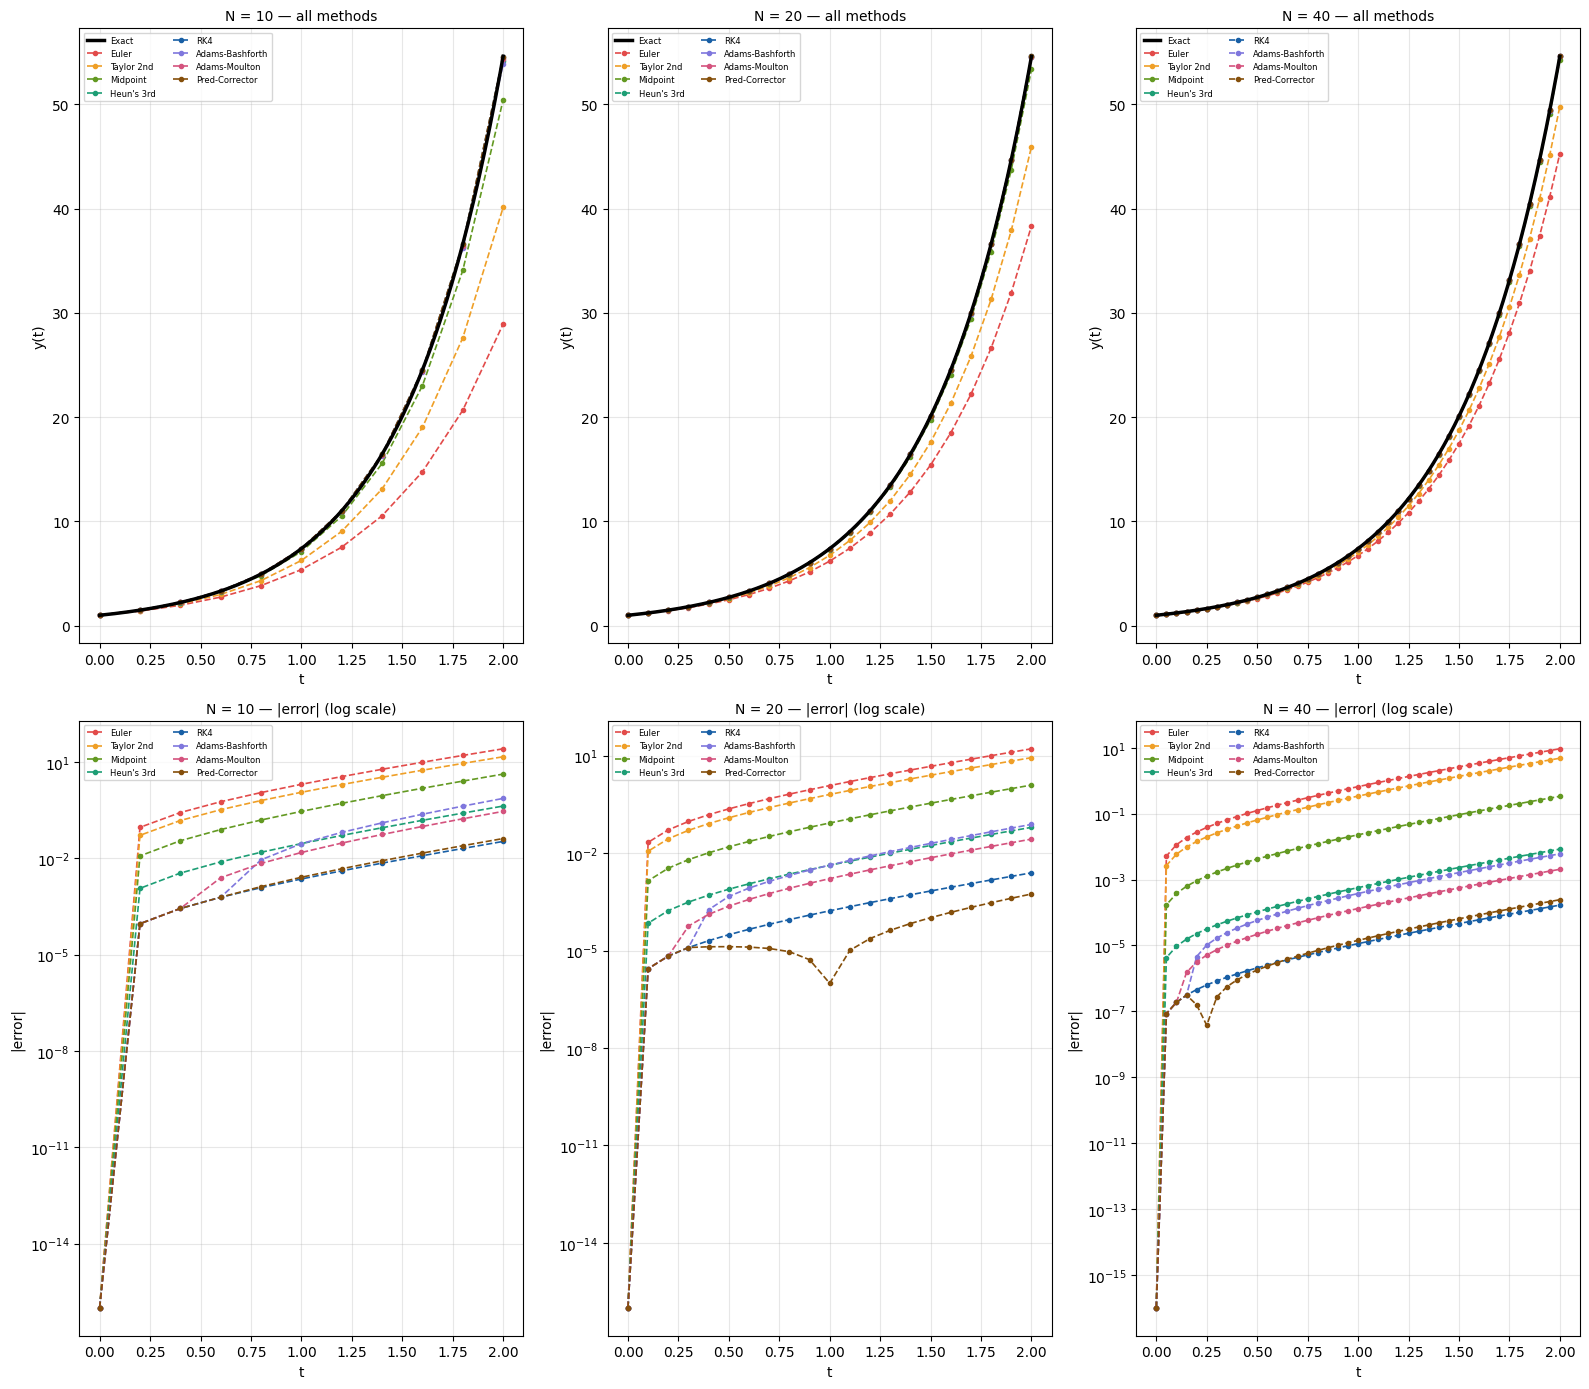

In [15]:
#plotting 
fig, axes = plt.subplots(2, 3, figsize=(16, 14))

for col, N in enumerate(N_s):
    t_fine = np.linspace(0, 2, 300)
    ax_top = axes[0][col]
    ax_top.plot(t_fine, y_exact_2(t_fine), 'k-', linewidth=2.5, label='Exact', zorder=10)
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results_2[N][key]
        ax_top.plot(t_m, w_m, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_top.set_title(f'N = {N} — all methods', fontsize=10)
    ax_top.set_xlabel('t')
    ax_top.set_ylabel('y(t)')
    ax_top.legend(fontsize=6, ncol=2)
    ax_top.grid(True, alpha=0.3)

    ax_mid = axes[1][col]
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results_2[N][key]
        err = np.abs(w_m - y_exact_2(t_m))   # ← fixed
        ax_mid.semilogy(t_m, err + 1e-16, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_mid.set_title(f'N = {N} — |error| (log scale)', fontsize=10)
    ax_mid.set_xlabel('t')
    ax_mid.set_ylabel('|error|')
    ax_mid.legend(fontsize=6, ncol=2)
    ax_mid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
#numerical tables and solution
for N in N_s:
    
    t_vals = results_2[N]['euler'][0]   # all methods share the same t 
    exact_vals_2 = y_exact_2(t_vals)

    data = {'t': t_vals, 'Exact': exact_vals_2}
    for key, label in zip(method_keys, method_labels):
        _, w = results_2[N][key]
        data[label] = w

    df = pd.DataFrame(data)

    max_row = {'t': 'max |error|', 'Exact': ''}
    for key, label in zip(method_keys, method_labels):
        _, w = results_2[N][key]
        max_row[label] = np.max(np.abs(w - y_exact_2(t_vals)))
    df = pd.concat([df, pd.DataFrame([max_row])], ignore_index=True)

    print(f'\n{"="*60}')
    print(f'  N = {N}  (h = {2/N:.4f})')
    print(f'{"="*60}')


    float_cols = [c for c in df.columns if c != 't']
    pd.set_option('display.float_format', '{:.8f}'.format)
    pd.set_option('display.max_columns', 20)
    pd.set_option('display.width', 220)
    print(df.to_string(index=False))



  N = 10  (h = 0.2000)
          t       Exact       Euler  Taylor 2nd    Midpoint  Heun's 3rd         RK4  Adams-Bashforth  Adams-Moulton  Pred-Corrector
 0.00000000  1.00000000  1.00000000  1.00000000  1.00000000  1.00000000  1.00000000       1.00000000     1.00000000      1.00000000
 0.20000000  1.49182470  1.40000000  1.44000000  1.48000000  1.49066667  1.49173333       1.49173333     1.49173333      1.49173333
 0.40000000  2.22554093  1.96000000  2.07567299  2.19040000  2.22208711  2.22526834       2.22526834     2.22526834      2.22526834
 0.60000000  3.32011692  2.74400000  2.99496382  3.24179200  3.31239119  3.31950696       3.31950696     3.31764964      3.31950696
 0.80000000  4.95303242  3.84160000  4.32575403  4.79785216  4.93767113  4.95181918       4.94411002     4.94611091      4.95172385
 1.00000000  7.38905610  5.37824000  6.25417693  7.10082120  7.36042176  7.38679372       7.36051784     7.37393550      7.38649862
 1.20000000 11.02317638  7.52953600  9.05140995 10.5

In [17]:
#error tables and analysis
method_keys   = ['euler', 'taylor', 'midpoint', 'heuns', 'RK4', 'adams_b', 'adams_m', 'pred_cor']
method_labels = ['Euler', 'Taylor 2nd', 'Midpoint', "Heun's 3rd", 'RK4',
                 'Adams-Bashforth', 'Adams-Moulton', 'Pred-Corrector']

for N in N_s:
    h = 2 / N
    t_vals     = results_2[N]['euler'][0]
    exact_vals_2 = y_exact_2(t_vals)

    data = {'t': np.round(t_vals, 4), 'Exact': exact_vals_2}
    for key, label in zip(method_keys, method_labels):
        _, w = results_2[N][key]
        data[label] = np.abs(w - exact_vals_2)

    df = pd.DataFrame(data)

    # format: exact in regular float, errors in scientific notation
    fmt = {'Exact': '{:.6f}'.format}
    for label in method_labels:
        fmt[label] = '{:.2e}'.format

    print(f'\nError table  |  h = {h}  (N = {N})\n')
    print(df.to_string(index=False, formatters=fmt))
    print()


Error table  |  h = 0.2  (N = 10)

         t     Exact    Euler Taylor 2nd Midpoint Heun's 3rd      RK4 Adams-Bashforth Adams-Moulton Pred-Corrector
0.00000000  1.000000 0.00e+00   0.00e+00 0.00e+00   0.00e+00 0.00e+00        0.00e+00      0.00e+00       0.00e+00
0.20000000  1.491825 9.18e-02   5.18e-02 1.18e-02   1.16e-03 9.14e-05        9.14e-05      9.14e-05       9.14e-05
0.40000000  2.225541 2.66e-01   1.50e-01 3.51e-02   3.45e-03 2.73e-04        2.73e-04      2.73e-04       2.73e-04
0.60000000  3.320117 5.76e-01   3.25e-01 7.83e-02   7.73e-03 6.10e-04        6.10e-04      2.47e-03       6.10e-04
0.80000000  4.953032 1.11e+00   6.27e-01 1.55e-01   1.54e-02 1.21e-03        8.92e-03      6.92e-03       1.31e-03
1.00000000  7.389056 2.01e+00   1.13e+00 2.88e-01   2.86e-02 2.26e-03        2.85e-02      1.51e-02       2.56e-03
1.20000000 11.023176 3.49e+00   1.97e+00 5.14e-01   5.12e-02 4.05e-03        6.40e-02      2.97e-02       4.71e-03
1.40000000 16.444647 5.90e+00   3.33e+00 8.9

Problem B investigates the exponentially growing solution $y=e^{2t}$. This problem is particularly useful for studying error amplification because any numerical error introduced during the computation is magnified by the rapid growth of the exact solution. The results show that lower-order methods struggle significantly with this behavior. For N=10, Euler's maximum error reaches approximately $25.67$, which is a substantial fraction of the exact solution value at $t=2$. The second-order Taylor method reduces the maximum error to about $14.49$, while the Midpoint method further lowers it to approximately $4.18$. Increasing the number of steps improves the accuracy of all methods, but the higher-order methods remain substantially more accurate. For $N=20$, RK4 achieves a maximum error of only $0.00246581$, compared with $16.26055011$ for Euler. At N=40, RK4's maximum error drops to approximately $1.67×10^{−4}$, while Euler still exhibits an error greater than $9.33$. Adams-Moulton and the Predictor-Corrector method also perform exceptionally well, maintaining errors on the order of $10^{−3}$ or smaller. The logarithmic error plots illustrate how truncation errors are amplified over time by the exponential growth of the solution. These results demonstrate the importance of both method order and stability when solving problems in which errors naturally grow throughout the integration interval.

Problem C)

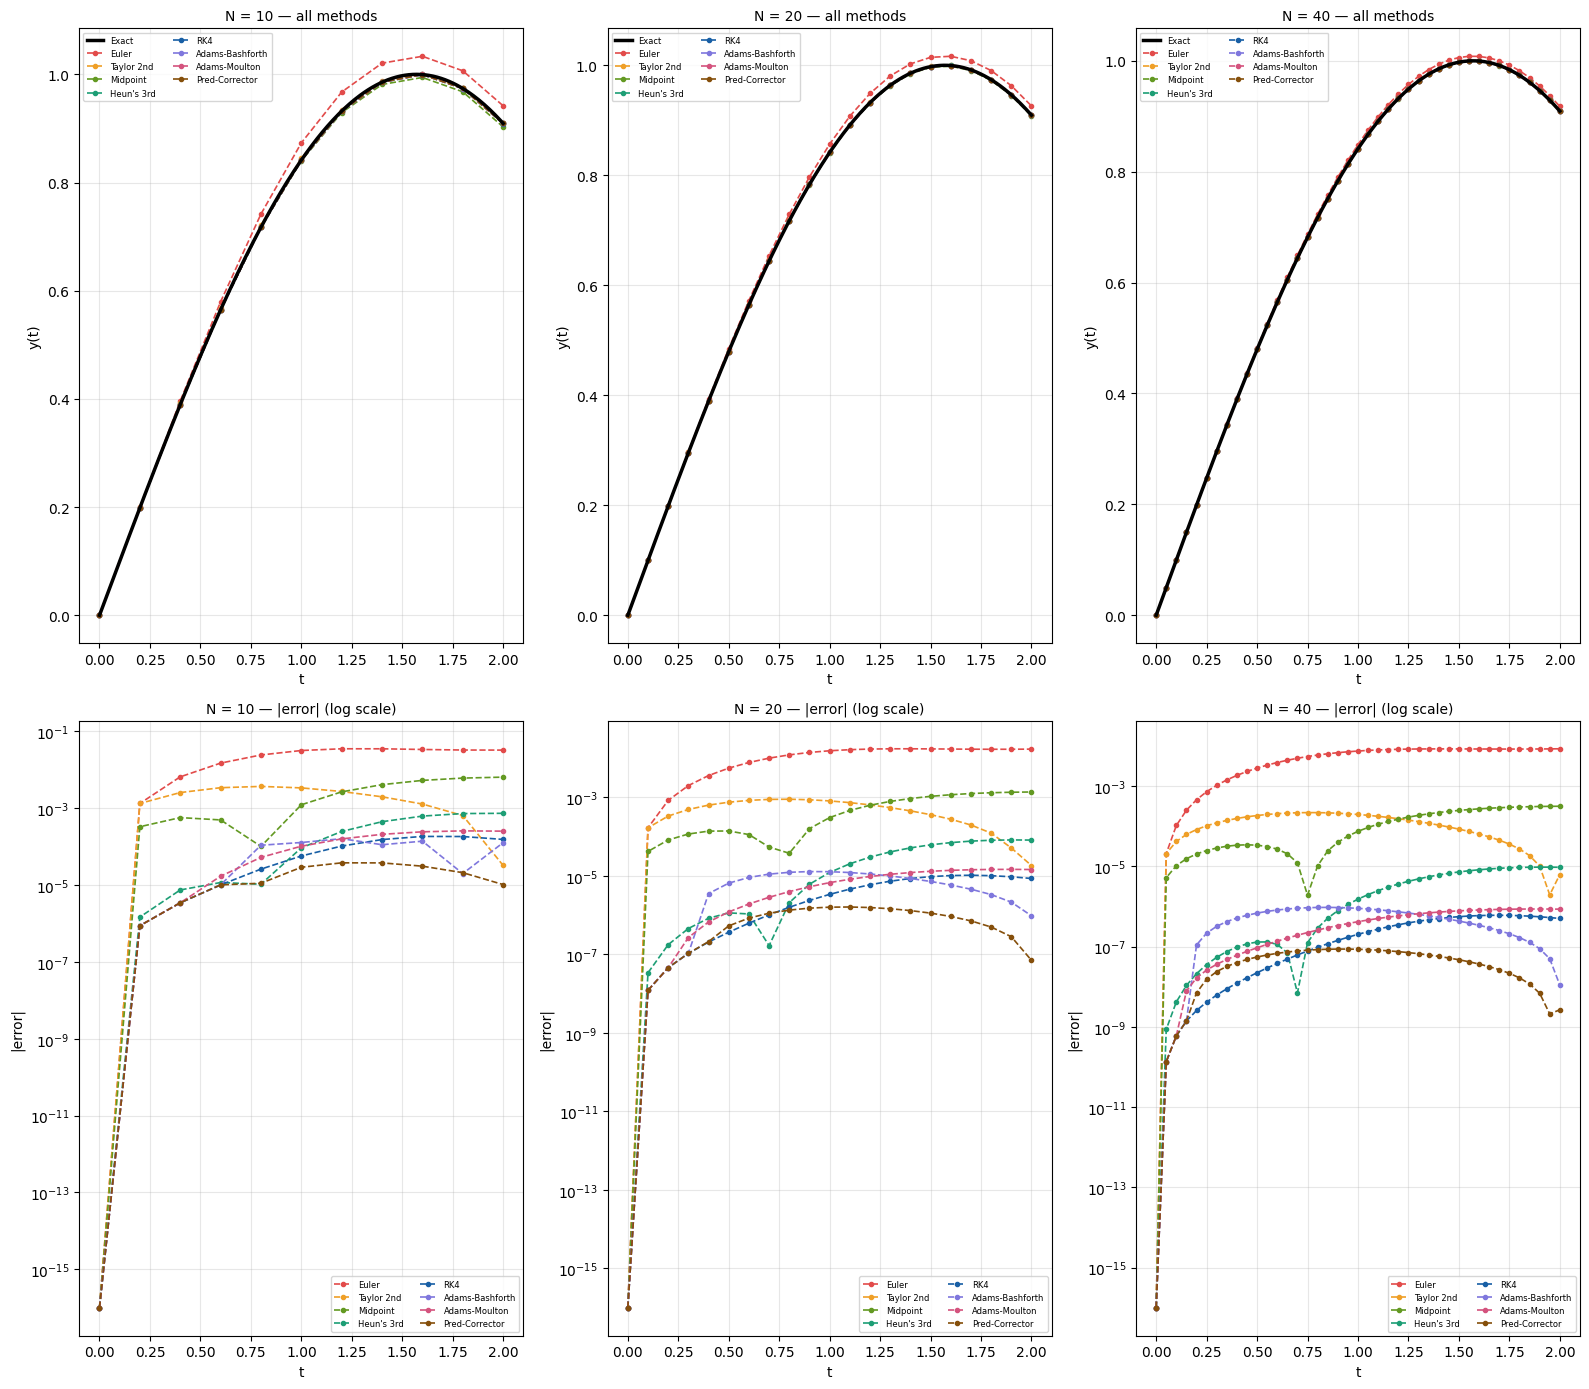

In [18]:
def f_3(t, y):
    #problem setting oscillation
    return -y**3 + np.cos(t) + np.sin(t)**3

def f_3_p(t, y):
    #first derivative
    return -np.sin(t) + 3*np.sin(t)**2 * np.cos(t) + (-3*y**2) * (-y**3 + np.cos(t) + np.sin(t)**3)

def y_exact_3(t):
    #exact solution
    return np.sin(t)

results_3 = {}
for N in N_s:
    results_3[N] = {
        'euler':     euler(f_3, 0, 2, N, alpha=0),
        'taylor':    taylor2(f_3, f_3_p, 0, 2, N, alpha=0),
        'midpoint':  midpoint(f_3, 0, 2, N, alpha=0),
        'heuns':     heuns(f_3, 0, 2, N, alpha=0),
        'RK4':       RK4(f_3, 0, 2, N, alpha=0),
        'adams_b':   adams_bashforth(f_3, 0, 2, N, alpha=0),
        'adams_m':   adams_moulten(f_3, 0, 2, N, alpha=0),
        'pred_cor':  predictor_corrector(f_3, 0, 2, N, alpha=0),
    }

#plotting
fig, axes = plt.subplots(2, 3, figsize=(16, 14))
for col, N in enumerate(N_s):
    t_fine = np.linspace(0, 2, 300)
    ax_top = axes[0][col]
    ax_top.plot(t_fine, y_exact_3(t_fine), 'k-', linewidth=2.5, label='Exact', zorder=10)
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results_3[N][key]
        ax_top.plot(t_m, w_m, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_top.set_title(f'N = {N} — all methods', fontsize=10)
    ax_top.set_xlabel('t')
    ax_top.set_ylabel('y(t)')
    ax_top.legend(fontsize=6, ncol=2)
    ax_top.grid(True, alpha=0.3)

    ax_mid = axes[1][col]
    for key, label, color in zip(method_keys, method_labels, colors):
        t_m, w_m = results_3[N][key]
        err = np.abs(w_m - y_exact_3(t_m))
        ax_mid.semilogy(t_m, err + 1e-16, '--o', color=color, markersize=3, linewidth=1.2, label=label)
    ax_mid.set_title(f'N = {N} — |error| (log scale)', fontsize=10)
    ax_mid.set_xlabel('t')
    ax_mid.set_ylabel('|error|')
    ax_mid.legend(fontsize=6, ncol=2)
    ax_mid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
#numerical tables
for N in N_s:
    
    t_vals = results_3[N]['euler'][0]   # all methods share the same t 
    exact_vals_3 = y_exact_3(t_vals)

    data = {'t': t_vals, 'Exact': exact_vals_3}
    for key, label in zip(method_keys, method_labels):
        _, w = results_3[N][key]
        data[label] = w

    df = pd.DataFrame(data)

    max_row = {'t': 'max |error|', 'Exact': ''}
    for key, label in zip(method_keys, method_labels):
        _, w = results_3[N][key]
        max_row[label] = np.max(np.abs(w - y_exact_3(t_vals)))
    df = pd.concat([df, pd.DataFrame([max_row])], ignore_index=True)

    print(f'\n{"="*60}')
    print(f'  N = {N}  (h = {2/N:.4f})')
    print(f'{"="*60}')


    float_cols = [c for c in df.columns if c != 't']
    pd.set_option('display.float_format', '{:.8f}'.format)
    pd.set_option('display.max_columns', 20)
    pd.set_option('display.width', 220)
    print(df.to_string(index=False))



  N = 10  (h = 0.2000)
          t      Exact      Euler  Taylor 2nd   Midpoint  Heun's 3rd        RK4  Adams-Bashforth  Adams-Moulton  Pred-Corrector
 0.00000000 0.00000000 0.00000000  0.00000000 0.00000000  0.00000000 0.00000000       0.00000000     0.00000000      0.00000000
 0.20000000 0.19866933 0.20000000  0.20000000 0.19899984  0.19866786 0.19866845       0.19866845     0.19866845      0.19866845
 0.40000000 0.38941834 0.39598159  0.39197739 0.38998907  0.38941087 0.38941488       0.38941488     0.38941488      0.38941488
 0.60000000 0.56464247 0.57958649  0.56806714 0.56513899  0.56463080 0.56463235       0.56463235     0.56465947      0.56463235
 0.80000000 0.71735609 0.74171861  0.72105403 0.71725447  0.71736663 0.71733003       0.71724708     0.71740875      0.71736726
 1.00000000 0.84147098 0.87327943  0.84485724 0.84023981  0.84156407 0.84141374       0.84134263     0.84157379      0.84150008
 1.20000000 0.93203909 0.96730899  0.93476804 0.92936915  0.93228787 0.93193533 

In [20]:
#error tables
method_keys   = ['euler', 'taylor', 'midpoint', 'heuns', 'RK4', 'adams_b', 'adams_m', 'pred_cor']
method_labels = ['Euler', 'Taylor 2nd', 'Midpoint', "Heun's 3rd", 'RK4',
                 'Adams-Bashforth', 'Adams-Moulton', 'Pred-Corrector']

for N in N_s:
    h = 2 / N
    t_vals     = results_3[N]['euler'][0]
    exact_vals_3 = y_exact_3(t_vals)

    data = {'t': np.round(t_vals, 4), 'Exact': exact_vals_3}
    for key, label in zip(method_keys, method_labels):
        _, w = results_3[N][key]
        data[label] = np.abs(w - exact_vals_3)

    df = pd.DataFrame(data)

    # format: exact in regular float, errors in scientific notation
    fmt = {'Exact': '{:.6f}'.format}
    for label in method_labels:
        fmt[label] = '{:.2e}'.format

    print(f'\nError table  |  h = {h}  (N = {N})\n')
    print(df.to_string(index=False, formatters=fmt))
    print()


Error table  |  h = 0.2  (N = 10)

         t    Exact    Euler Taylor 2nd Midpoint Heun's 3rd      RK4 Adams-Bashforth Adams-Moulton Pred-Corrector
0.00000000 0.000000 0.00e+00   0.00e+00 0.00e+00   0.00e+00 0.00e+00        0.00e+00      0.00e+00       0.00e+00
0.20000000 0.198669 1.33e-03   1.33e-03 3.31e-04   1.47e-06 8.78e-07        8.78e-07      8.78e-07       8.78e-07
0.40000000 0.389418 6.56e-03   2.56e-03 5.71e-04   7.47e-06 3.46e-06        3.46e-06      3.46e-06       3.46e-06
0.60000000 0.564642 1.49e-02   3.42e-03 4.97e-04   1.17e-05 1.01e-05        1.01e-05      1.70e-05       1.01e-05
0.80000000 0.717356 2.44e-02   3.70e-03 1.02e-04   1.05e-05 2.61e-05        1.09e-04      5.27e-05       1.12e-05
1.00000000 0.841471 3.18e-02   3.39e-03 1.23e-03   9.31e-05 5.72e-05        1.28e-04      1.03e-04       2.91e-05
1.20000000 0.932039 3.53e-02   2.73e-03 2.67e-03   2.49e-04 1.04e-04        1.61e-04      1.59e-04       3.80e-05
1.40000000 0.985450 3.52e-02   1.99e-03 4.11e-03   4

Problem C uses the nonlinear differential equation $y^{'} = -y^3 + cos(t) + sin^3 (t)$ with exact solution $y(t)=sin(t)$. This problem was selected because it contains a nonlinear term while still having a known analytical solution for comparison. The cubic damping term $−y^3$ helps suppress excessive growth, making the problem more stable than the exponential-growth problem studied in Problem B. As expected, all methods perform better in this setting. For $N=10$, Euler's error near the final time remains on the order of $10^{−2}$, while Taylor's method reduces the error to approximately $10^−3$. The higher-order methods perform significantly better, with RK4, Adams-Moulton, and the Predictor-Corrector method producing errors between $10^{−5}$ and $10^{−7}$ across most of the interval. As the step size is reduced from $h=0.2$ to $h=0.05$, all methods exhibit the expected decrease in error, with higher-order methods converging much more rapidly than Euler's method. By $N=40$, RK4 and the Predictor-Corrector method maintain errors that are extremely small and nearly indistinguishable from the exactsolution on the plots. These results show that nonlinear terms do not necessarily create numerical difficulties when stabilizing effects are present. The observed behavior agrees closely with theoretical expectations regarding convergence order, error propagation, and numerical stability, with RK4 and the corrected multistep methods providing the best balance of accuracy and efficiency.

Error Analysis:

Across all three problems, the observed errors agree with theoretical predictions. Euler (order 1) converges slowest, Taylor and Midpoint (order 2) converge moderately, Heun's (order 3) is better still, and RK4 and multi-step methods (order 4) are consistently the most accurate. Methods with the same formal order can still differ due to their leading error constants — for example, Adams-Moulton outperforms Adams-Bashforth because its implicit corrector step reduces the error constant. All methods remained stable within the step sizes tested, though Euler and Taylor would be first to lose stability if h were increased. Error propagation was well-behaved across all problems, with the nonlinear damping in Problem C actually helping to suppress error growth.

Conclusion:

Higher-order methods achieve dramatically better accuracy for the same computational cost. RK4 strikes the best balance for single-step integration, self-starting, stable, and 4th-order accurate. Multi-step methods match RK4's accuracy with fewer evaluations per step, but require carefulness and are more sensitive to initialization errors. The Predictor-Corrector is the most sophisticated method studied, combining explicit and implicit steps to achieve near-implicit accuracy without a nonlinear solve. Correct problem setup — particularly initial conditions — proved just as important as method choice, as an incorrect initial condition rendered all methods inaccurate regardless of their order.